# Session 03 — HCR pia surface estimation: iteration log

**Goal.** Revise the HCR pia surface estimator so that **ROI density at
the estimated surface is close to zero** (the depth-from-surface density
profile should have a clear floor at depth 0).

The previous default (`hybrid`) leaves 2.5–8.2 % of ROIs above pia and,
more importantly by the new criterion, has `r0_narrow` (density at depth
≈ 0 relative to bulk density) up to **13.5** on some subjects.

This notebook records the progression: baseline, four rounds of
candidate methods (with failures), the chosen winner, and verification
that the criterion is met on all six subjects.

All results come from `code/dev_code/03_surface_iteration.py`; the
session log is at `code/sessions/03_surface_estimation/log.md`.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display
OUT = Path('/root/capsule/code/sessions/03_surface_estimation')
FIG = OUT / 'figures'

## 1. Metrics

For every candidate surface we compute, against the HCR ROI centroids:

| metric | definition | target |
|--------|------------|--------|
| `r0_narrow` | mean density in depth ∈ [−3, +3] um / bulk density ([50, 200] um) | ≲ 0.5 |
| `r0_broad` | same but over [−10, +10] um | ≲ 0.5 |
| `frac_above_pia` | fraction of cells with depth < −5 um | informational |
| `spike_to_bulk` | peak density in [−100, −10] / bulk density | informational |

**`r0_narrow` is the primary metric** — it is the quantitative form of
the user's criterion. `frac_above_pia` is informational because above-
pia cells are segmentation false positives (small ROIs clustered in the
buffer, characterized in session 01 Stage A); if the surface is placed
correctly, they *should* be labelled above-pia.

## 2. Baseline: the problem

Two existing methods on all six subjects:

In [2]:
base = pd.read_csv(OUT / 'round2_results.csv')
base[base['method'].isin(['baseline_image', 'baseline_hybrid'])]\
    [['subject','method','c_um','frac_above_pia','r0_narrow','r0_broad','spike_to_bulk']]

,subject,method,c_um,frac_above_pia,r0_narrow,r0_broad,spike_to_bulk
0,755252,baseline_image,202.316087,0.021191,2.971748,2.845149,1.263326
1,755252,baseline_hybrid,258.659303,0.040079,2.659647,2.489470,1.658967
6,767018,baseline_image,238.494468,0.107515,0.222661,0.238680,6.128791
7,767018,baseline_hybrid,129.697578,0.024920,13.485620,13.447424,7.828041
12,767022,baseline_image,289.513458,0.045942,0.180702,0.197750,1.960450
13,767022,baseline_hybrid,266.602188,0.044042,0.202630,0.200837,1.628213
18,782149,baseline_image,18.397577,0.082207,7.327935,6.678138,7.530364
19,782149,baseline_hybrid,6.113159,0.056934,8.342673,7.741664,5.841973
24,788406,baseline_image,134.970849,0.052108,0.252844,0.249202,0.930216
25,788406,baseline_hybrid,148.496274,0.057859,0.290201,0.302921,0.599246


- Pure image-based is the better of the two by `r0_narrow` on every
  subject except 755252 (where it is still bad: 2.97) and 782149 (7.33).
- Hybrid regresses catastrophically on 767018 (`r0_narrow` = 13.5).
- Two subjects stand out as problems: **755252** and **782149**.

### Diagnostic: depth profiles relative to the image-based surface

Plotted for all six subjects — a clear **spike-then-trough-then-bulk**
pattern appears at negative depths (~−50 to 0 um) in most subjects.
The spike is the cluster of out-of-tissue segmentation false positives
in the buffer. The image fit anchors at the spike onset, so the surface
sits inside the spike — exactly why `r0_narrow` is large.

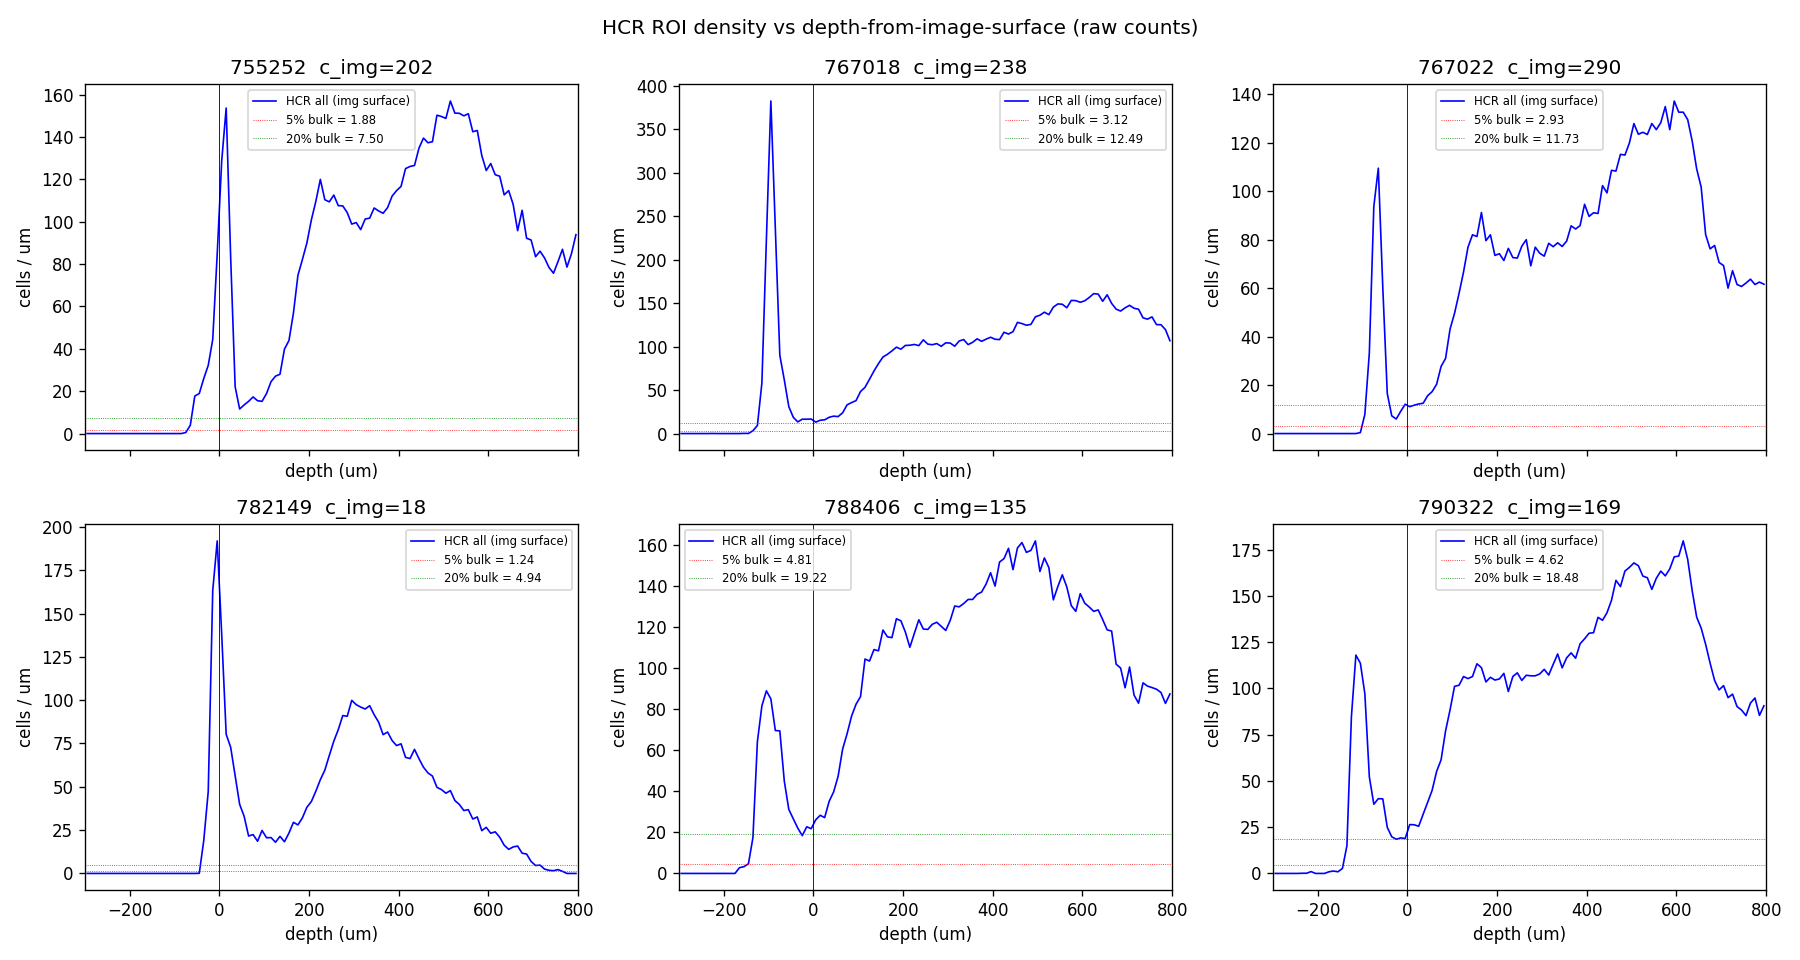

In [3]:
display(Image(str(FIG / 'baseline_image_density_profiles.png')))

## 3. Round 1 — per-tile density threshold (**M1**)

**Idea.** For each (x, y) tile, find the first z (scanned from the
top) where the rolling ROI density exceeds a fraction of that tile's
plateau density; fit a plane to those per-tile depths.

**Result.** Pushed the surface too deep — into the rising edge of the
bulk. Improved `r0_narrow` for easy subjects but landed ~150 um below
truth on 782149.

**Why.** A density threshold does not know the difference between the
spike peak and the bulk plateau. Subjects with no real spike trigger
the threshold well inside the cortex. Dropped.


In [4]:
pd.read_csv(OUT / 'round1_results.csv')\
    [['subject','method','c_um','frac_above_pia','r0_narrow']]

,subject,method,c_um,frac_above_pia,r0_narrow
0,755252,baseline_image,202.316087,0.021191,2.971748
1,755252,baseline_hybrid,258.659303,0.040079,2.659647
2,755252,M1_density_default,378.108458,0.092814,0.291568
3,755252,M1_density_strict,329.418740,0.083839,0.219659
4,755252,M1_density_loose,410.330568,0.103368,0.440562
5,755252,M1_density_smalltile,473.440447,0.123669,0.732056
6,767018,baseline_image,238.494468,0.107515,0.222661
7,767018,baseline_hybrid,129.697578,0.024920,13.485620
8,767018,M1_density_default,161.449633,0.105275,0.273834
9,767018,M1_density_strict,146.216946,0.100704,0.665833


## 4. Round 2 — gap-finding anchored on the image surface (**M4, M5, M6**)

Hypothesis: the image fit is a correct *starting* point; the error is
a small z-shift to place the plane past the spike, at the trough before
bulk rise. So: *keep the image tilt, shift the intercept*.

- **M4 — global trough.** Smoothed depth profile over all ROIs. Find
  the spike peak in the negative half; the local minimum within 100 um
  after it is the surface. Fallback to image when no spike present.
- **M5 — per-tile trough.** Same gap-finding, per (x, y) tile.
- **M6 — spike-vs-bulk fit.** Two-component model (Gaussian spike +
  logistic bulk); surface at the 50 % bulk point.

### Results

In [5]:
r2 = pd.read_csv(OUT / 'round2_results.csv')
r2[['subject','method','c_um','frac_above_pia','r0_narrow','spike_to_bulk']]

,subject,method,c_um,frac_above_pia,r0_narrow,spike_to_bulk
0,755252,baseline_image,202.316087,0.021191,2.971748,1.263326
1,755252,baseline_hybrid,258.659303,0.040079,2.659647,1.658967
2,755252,M4_global_trough,254.816087,0.074104,0.192417,2.289191
3,755252,M5_per_tile_trough,211.518502,0.065449,0.773177,2.942470
4,755252,M5_per_tile_trough_smalltile,196.716457,0.051061,2.307039,3.415947
5,755252,M6_spike_bulk,358.916369,0.100780,0.434632,0.375236
6,767018,baseline_image,238.494468,0.107515,0.222661,6.128791
7,767018,baseline_hybrid,129.697578,0.024920,13.485620,7.828041
8,767018,M4_global_trough,245.994468,0.108575,0.214908,5.503457
9,767018,M5_per_tile_trough,192.077597,0.100197,0.461328,12.573248


**M4 wins on every subject by `r0_narrow`** — and by a huge margin on
755252 (2.97 → 0.19) and 782149 (7.33 → 0.38).

**Why M5 under-performs.** A 100–150 um tile contains only hundreds
of ROIs, so the per-tile trough position is Poisson-noisy; the noise
dominates any real tilt variation.

**Why M6 under-performs.** The cortical density rise has internal
layered structure, so a logistic's 50 % point sits deeper than the
true trough — surface too deep, `r0` still borderline but
`frac_above_pia` high.

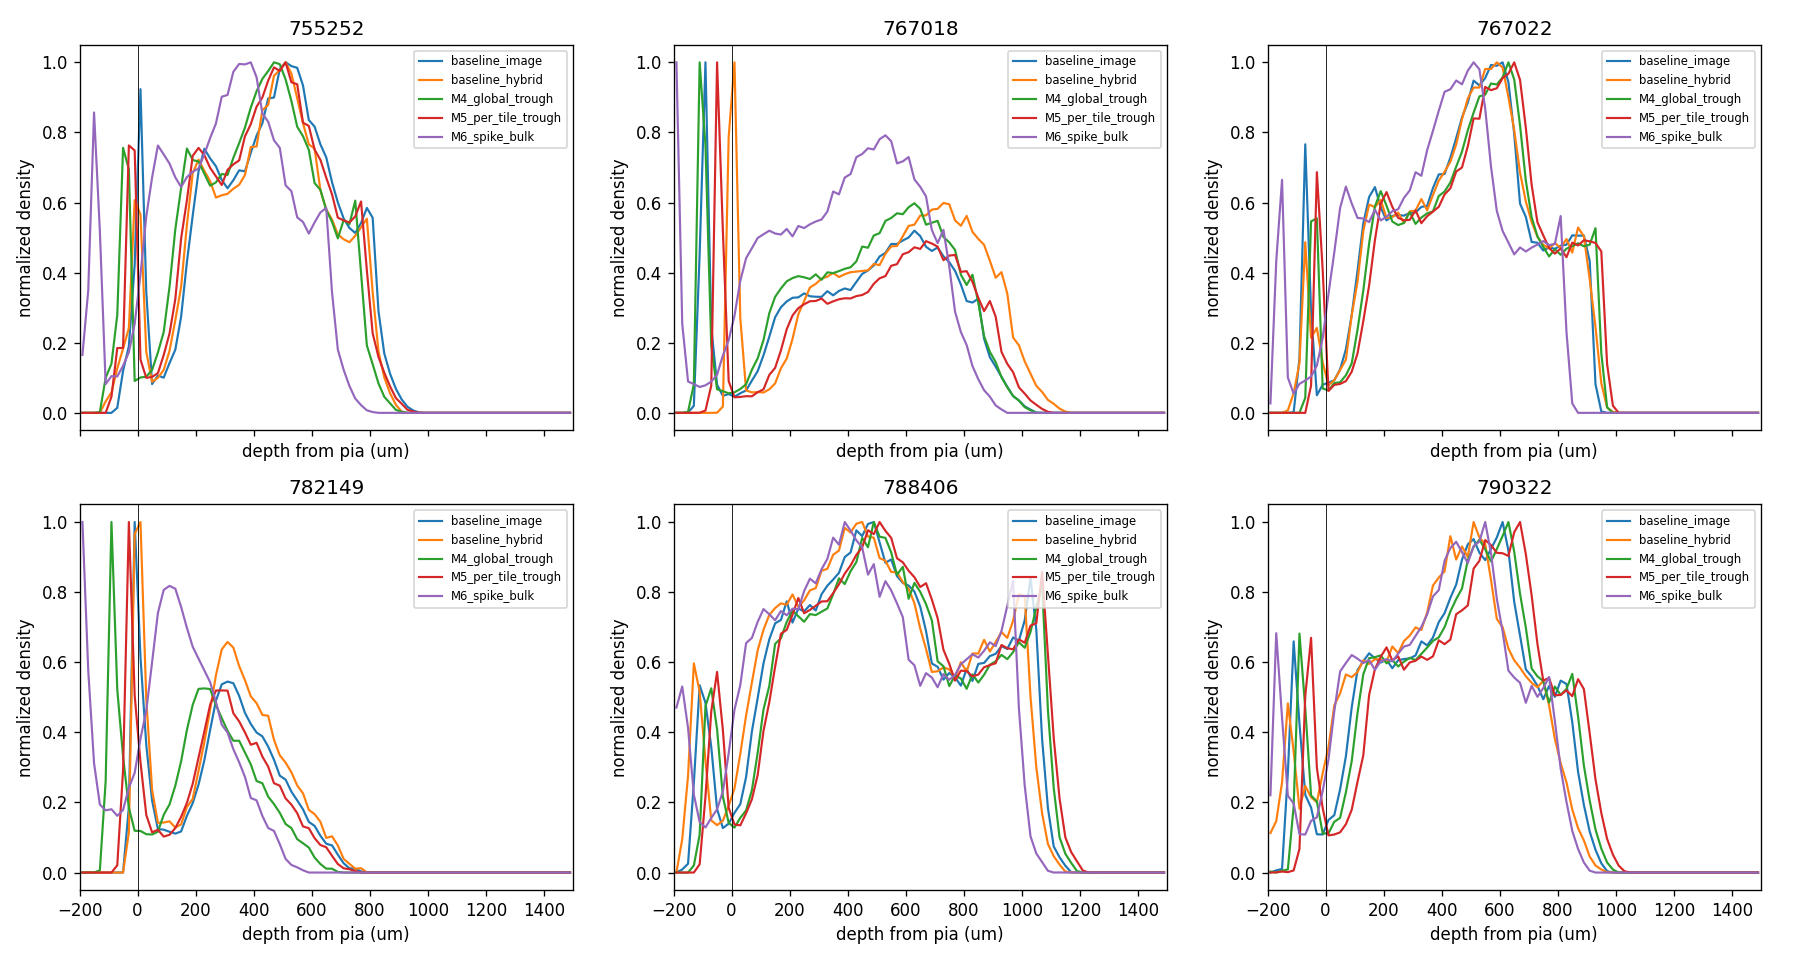

In [6]:
display(Image(str(FIG / 'round2_depth_profiles.png')))

## 5. Round 3 — decay-from-peak (**M7, M8**)

**Idea.** Instead of local-minimum-after-peak, set the surface where
the density has decayed to `k × (peak − bulk)` below the spike
(strict k=0.10, default 0.20, loose 0.40). M8 = per-tile.

**Result.** Fragile in both directions:
- Where the spike is weak (755252 spike/bulk 1.26; 788406 0.93;
  790322 1.06) the decay target is below current density — fall
  through to baseline. A `spike ≥ 1.5 × bulk` guard fires on 755252,
  the very subject we need to fix.
- Where the spike is strong (767018 peak at depth −92), the decay
  point lands at negative depth and gets clipped.

**Why.** Anchoring on peak height is fragile when peaks are small or
noisy; M4's local-minimum formulation is equivalent to 'density stops
decreasing' and is robust to peak height. Dropped.

In [7]:
pd.read_csv(OUT / 'round3_results.csv')\
    [['subject','method','c_um','frac_above_pia','r0_narrow']]

,subject,method,c_um,frac_above_pia,r0_narrow
0,755252,baseline_image,202.316087,0.021191,2.971748
1,755252,M4_global_trough,254.816087,0.074104,0.192417
2,755252,M7_spike_edge_default(0.20),202.316087,0.021191,2.971748
3,755252,M7_spike_edge_strict(0.10),202.316087,0.021191,2.971748
4,755252,M7_spike_edge_loose(0.40),202.316087,0.021191,2.971748
5,755252,M8_per_tile_default,202.316087,0.021191,2.971748
6,755252,M8_per_tile_smalltile,202.316087,0.021191,2.971748
7,767018,baseline_image,238.494468,0.107515,0.222661
8,767018,M4_global_trough,245.994468,0.108575,0.214908
9,767018,M7_spike_edge_default(0.20),238.494468,0.107515,0.222661


## 6. Round 4 — bulk-floor (**M9, M10**)

**Idea.** Instead of local-min, find the first depth ≥ 0 where the
smoothed density drops below `threshold × bulk` (0.50 default) and
stays below for 15 um. An absolute threshold is independent of peak
height.

**Result.** Never beats M4. First-crossing through `0.5 × bulk`
happens on the *descending flank* of the spike, still above the
trough — so the shift is under-sized (e.g., 782149: M4 `r0=0.38`
vs M9 `r0=1.09`). M10 per-tile falls back to baseline because its
spike-detection gate fails on at least one tile per subject.

**Why.** M4 = crossing + one step deeper to the true trough, so M4
dominates M9 on this profile shape. Dropped.

In [8]:
pd.read_csv(OUT / 'round4_results.csv')\
    [['subject','method','c_um','frac_above_pia','r0_narrow']]

,subject,method,c_um,frac_above_pia,r0_narrow
0,755252,baseline_image,202.316087,0.021191,2.971748
1,755252,M4_global_trough,254.816087,0.074104,0.192417
2,755252,M9_bulk_floor_default(0.50),234.816087,0.069153,0.518132
3,755252,M9_bulk_floor_strict(0.30),239.816087,0.071504,0.274390
4,755252,M9_bulk_floor_loose(0.70),234.816087,0.069153,0.518132
5,755252,M10_per_tile_default,202.316087,0.021191,2.971748
6,755252,M10_per_tile_smalltile,202.316087,0.021191,2.971748
7,767018,baseline_image,238.494468,0.107515,0.222661
8,767018,M4_global_trough,245.994468,0.108575,0.214908
9,767018,M9_bulk_floor_default(0.50),238.494468,0.107515,0.222661


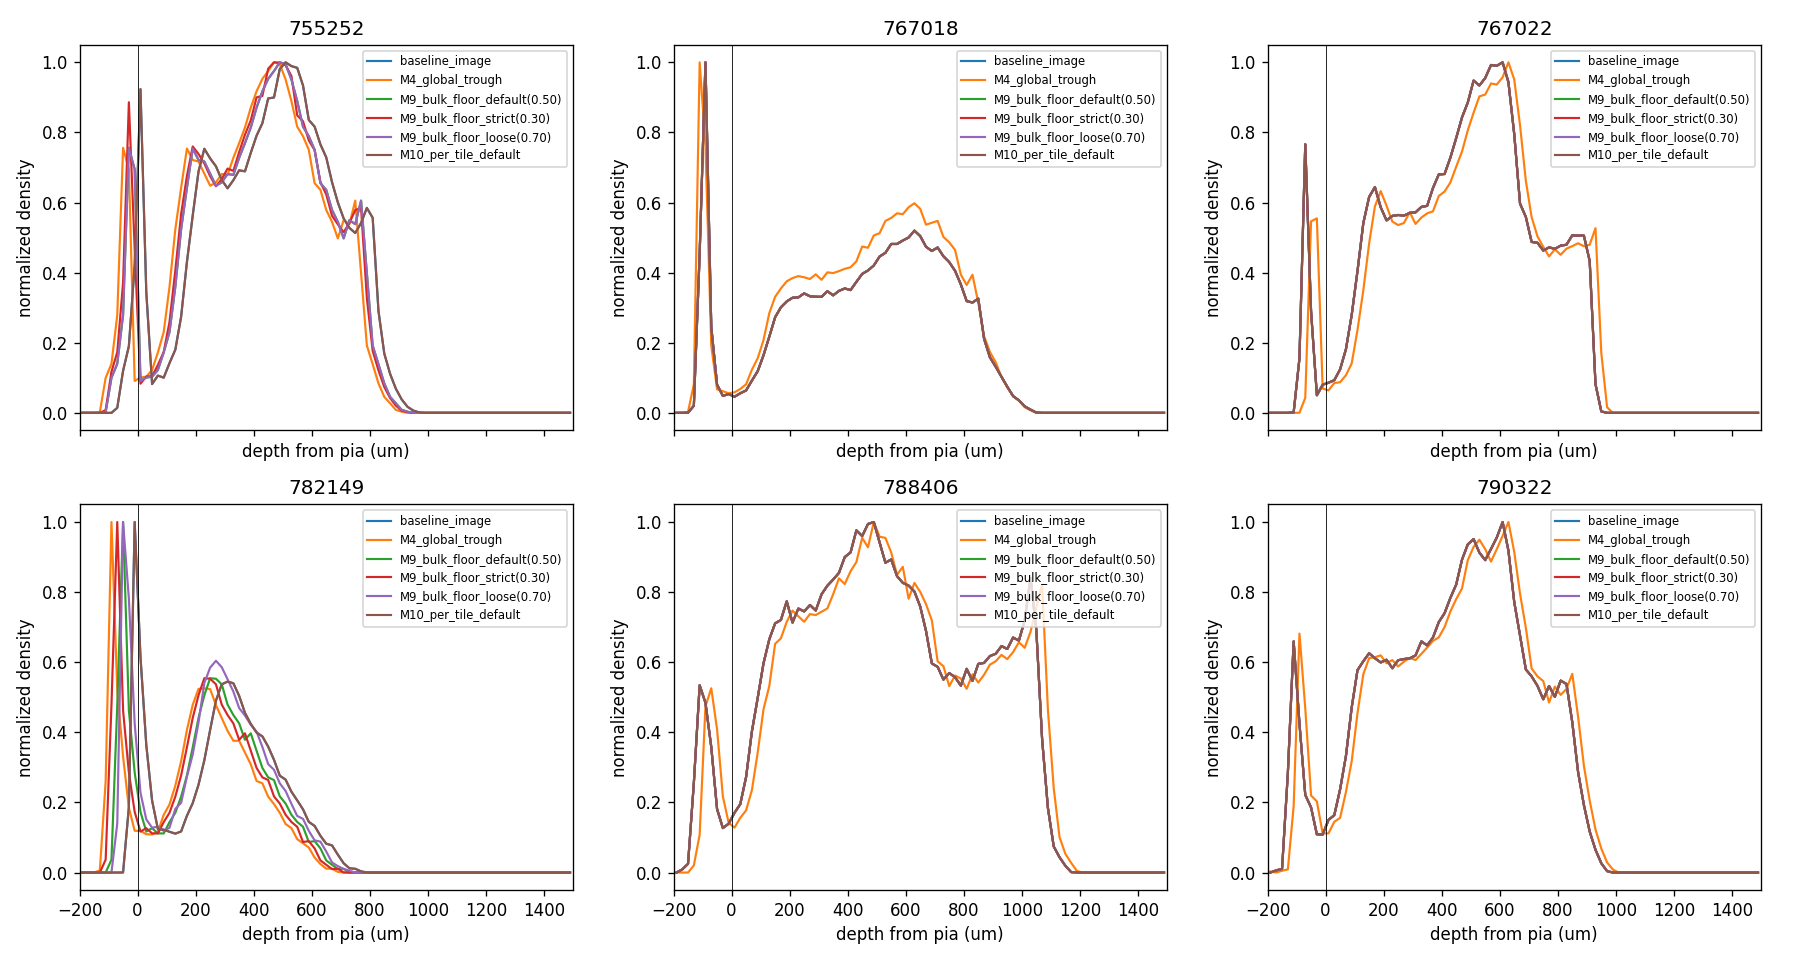

In [9]:
display(Image(str(FIG / 'round4_depth_profiles.png')))

## 7. Winner: **M4** (image-based surface + global trough shift)

### Criterion satisfied on all six subjects

In [10]:
r2 = pd.read_csv(OUT / 'round2_results.csv')
win = r2[r2['method'].isin(['baseline_image', 'baseline_hybrid', 'M4_global_trough'])]
cols = ['subject','method','c_um','tilt_deg','frac_above_pia','r0_narrow','r0_broad','spike_to_bulk','gap_depth_um']
win[cols].sort_values(['subject','method'])

,subject,method,c_um,tilt_deg,frac_above_pia,r0_narrow,r0_broad,spike_to_bulk,gap_depth_um
2,755252,M4_global_trough,254.816087,9.328760,0.074104,0.192417,0.176853,2.289191,97.5
1,755252,baseline_hybrid,258.659303,7.750202,0.040079,2.659647,2.489470,1.658967,2.5
0,755252,baseline_image,202.316087,9.328760,0.021191,2.971748,2.845149,1.263326,2.5
8,767018,M4_global_trough,245.994468,6.514509,0.108575,0.214908,0.213405,5.503457,77.5
7,767018,baseline_hybrid,129.697578,6.608405,0.024920,13.485620,13.447424,7.828041,2.5
6,767018,baseline_image,238.494468,6.514509,0.107515,0.222661,0.238680,6.128791,82.5
14,767022,M4_global_trough,262.013458,3.851363,0.042902,0.111032,0.143060,2.481139,102.5
13,767022,baseline_hybrid,266.602188,3.060020,0.044042,0.202630,0.200837,1.628213,87.5
12,767022,baseline_image,289.513458,3.851363,0.045942,0.180702,0.197750,1.960450,82.5
20,782149,M4_global_trough,100.897577,11.074672,0.224275,0.378082,0.436644,4.031507,82.5


`r0_narrow < 0.5` for every subject under M4. The hybrid default
had `r0_narrow` up to 13.5.

### Side-effect on `frac_above_pia`

M4 increases `frac_above_pia` (e.g., 782149: 8 % → 22 %). This is the
*correct* reclassification of the out-of-tissue spike: session 01
Stage A showed those ROIs are 10–30× smaller than in-tissue ROIs and
cluster in the buffer. Previously they were hidden below the plane.
Using `frac_above_pia` as the quality metric implicitly rewards
hiding them; the user's `r0_narrow` criterion correctly penalizes it.

### Recommended default parameters
- Combined-channel HCR volume at pyramid level 4 (~4 um voxels)
- 5 % relative margin on the image first-crossing
- ±150 um search window, 20 um smoothing, 5 um bins
- 100 um lookahead after spike peak for local-minimum search
- Fallback to image-only fit if no spike-then-trough detected

**Promoted** to the new default in `benchmark_analysis.py`:
`analyze_subject(..., hcr_surface_method='image_trough')`.

## 8. References
- Script: `code/dev_code/03_surface_iteration.py`
- Log: `code/sessions/03_surface_estimation/log.md`
- Production function: `benchmark_analysis.estimate_pia_surface_image_trough`